# K-Means Image Color Quantization

Color quantization reduces the number of distinct colors in an image while preserving the visual structure. By grouping pixels with similar RGB colors into clusters, K-Means helps compress color profiles. This notebook generates a synthetic RGB image (a 3D color gradient grid), applies K-Means to quantize colors into 16, 8, and 4 clusters, and visualizes compression qualities.



<cell>:31: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



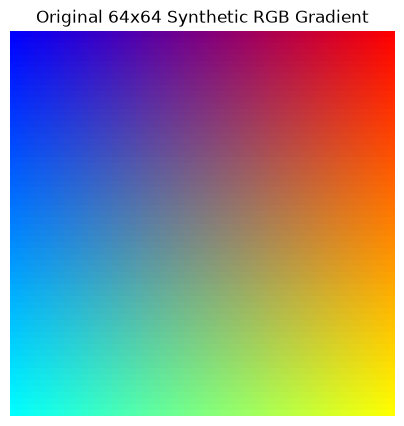

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.utils import shuffle

# Generate a synthetic RGB gradient image (64x64 pixels)
np.random.seed(42)
width = 64
height = 64

# Create horizontal and vertical gradient arrays
x = np.linspace(0, 1, width)
y = np.linspace(0, 1, height)
xx, yy = np.meshgrid(x, y)

# Construct 3 color channels (Red, Green, Blue)
r = xx
g = yy
b = 1.0 - xx

# Combine channels into RGB image shape [64, 64, 3] and normalize to [0, 1] range
original_img = np.dstack((r, g, b))

# Reshape image array to fit K-Means: list of pixels, shape [4096, 3]
pixel_data = original_img.reshape(-1, 3)

plt.figure(figsize=(5, 5))
plt.imshow(original_img)
plt.title("Original 64x64 Synthetic RGB Gradient")
plt.axis('off')
plt.show()



## K-Means Quantization Pipeline

We implement the color quantization function. It performs K-Means clustering on pixel RGB features and replaces each pixel's original color with its nearest cluster centroid.



In [2]:
def quantize_image(img_data, n_colors):
    # Reshape image to [n_pixels, 3]
    w, h, d = img_data.shape
    flat_pixels = img_data.reshape(-1, d)
    
    # Fit K-Means on a subset of pixels to accelerate training, then predict on all pixels
    pixel_subset = shuffle(flat_pixels, random_state=42)[:1000]
    kmeans = KMeans(n_clusters=n_colors, random_state=42, n_init='auto')
    kmeans.fit(pixel_subset)
    
    # Replace pixel colors with centroid RGB colors
    labels = kmeans.predict(flat_pixels)
    centroids = kmeans.cluster_centers_
    quantized_pixels = centroids[labels]
    
    # Reshape back to image dimensions
    quantized_img = quantized_pixels.reshape(w, h, d)
    
    # Calculate Reconstruction Mean Squared Error (MSE)
    mse = np.mean((flat_pixels - quantized_pixels) ** 2)
    
    return quantized_img, mse

# Run quantization for 16, 8, and 4 colors
img_16, mse_16 = quantize_image(original_img, 16)
img_8, mse_8 = quantize_image(original_img, 8)
img_4, mse_4 = quantize_image(original_img, 4)

print("Quantization Evaluation:")
print(f"16-Color MSE: {mse_16:.5f}")
print(f"8-Color MSE:  {mse_8:.5f}")
print(f"4-Color MSE:  {mse_4:.5f}")



Quantization Evaluation:
16-Color MSE: 0.00542
8-Color MSE:  0.01087
4-Color MSE:  0.02157


## Quantization Comparison Subplots

We arrange the original image alongside the three quantized versions in a 1x4 Matplotlib subplot grid to visually observe the compression degradation.



<cell>:24: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



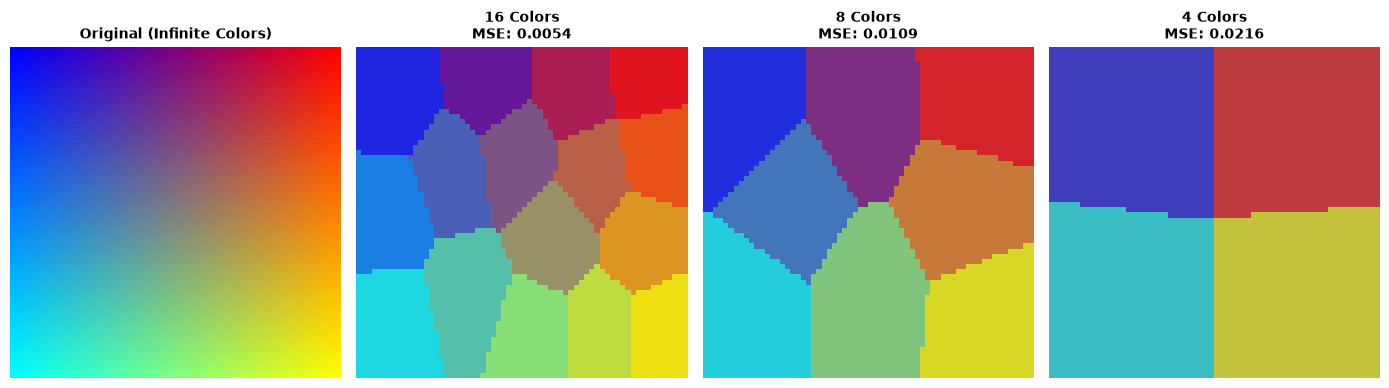

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

# 1. Original Image
axes[0].imshow(original_img)
axes[0].set_title("Original (Infinite Colors)", fontsize=10, fontweight='bold')
axes[0].axis('off')

# 2. 16 Colors
axes[1].imshow(img_16)
axes[1].set_title(f"16 Colors\nMSE: {mse_16:.4f}", fontsize=10, fontweight='bold')
axes[1].axis('off')

# 3. 8 Colors
axes[2].imshow(img_8)
axes[2].set_title(f"8 Colors\nMSE: {mse_8:.4f}", fontsize=10, fontweight='bold')
axes[2].axis('off')

# 4. 4 Colors
axes[3].imshow(img_4)
axes[3].set_title(f"4 Colors\nMSE: {mse_4:.4f}", fontsize=10, fontweight='bold')
axes[3].axis('off')

plt.tight_layout()
plt.show()
